# Customer Churn Prediction using Data Analytics and Machine Learning

**Program:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 (BharatCares)
**Author:** YourName
**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 features)

---

## 1. Problem Statement
Customer churn (customers leaving a service) is one of the costliest problems in the telecom industry, because acquiring a new customer is far more expensive than retaining an existing one. 

**Goal:** Analyse customer behaviour to understand *why* customers churn, build machine learning models that *predict* which customers are likely to churn, and turn the results into practical retention recommendations.

## 2. Workflow
1. Load and inspect the data
2. Clean the data
3. Exploratory Data Analysis (EDA)
4. Feature engineering
5. Build and compare ML models
6. Tune the best model
7. Explain the model (feature importance)
8. Customer risk scoring
9. Business insights and recommendations

## 3. Import Libraries

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 12
RANDOM_STATE = 42

# Folders for saved charts and results
os.makedirs("images", exist_ok=True)
os.makedirs("results", exist_ok=True)

## 4. Load the Dataset

In [2]:
LOCAL_PATH = "data/Telco-Customer-Churn.csv"
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Use the local copy if present, otherwise download directly from the IBM GitHub repository
df = pd.read_csv(LOCAL_PATH if os.path.exists(LOCAL_PATH) else URL)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Data Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Summary statistics for numeric columns
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [5]:
# Missing values and duplicates
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Missing values per column:
 Series([], dtype: int64)

Duplicate rows: 0
Duplicate customer IDs: 0


**Observation:** `TotalCharges` is stored as text (object) even though it should be numeric. This usually means some values are blank strings. We handle this in the cleaning step.

## 6. Data Cleaning

In [6]:
df_clean = df.copy()

# TotalCharges: convert to numeric (blank strings become NaN)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
blank_rows = df_clean[df_clean["TotalCharges"].isnull()]
print(f"Rows with blank TotalCharges: {len(blank_rows)}")
print("Their tenure values:", blank_rows["tenure"].unique())

Rows with blank TotalCharges: 11
Their tenure values: [0]


All rows with a blank `TotalCharges` have `tenure = 0`, i.e. brand-new customers who have not been billed yet. So the correct value is **0**, not the mean or median.

In [7]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

# SeniorCitizen is coded 0/1 while other flags are Yes/No; make it consistent
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Drop the identifier (no predictive value) but keep a copy for the final risk report
customer_ids = df_clean["customerID"]
df_clean = df_clean.drop(columns=["customerID"])

# Target variable: Yes -> 1, No -> 0
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

print("Remaining missing values:", df_clean.isnull().sum().sum())
df_clean.head()

Remaining missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 7. Exploratory Data Analysis (EDA)

### 7.1 Overall churn rate

Churned customers: 1869 (26.5%)
Retained customers: 5174 (73.5%)


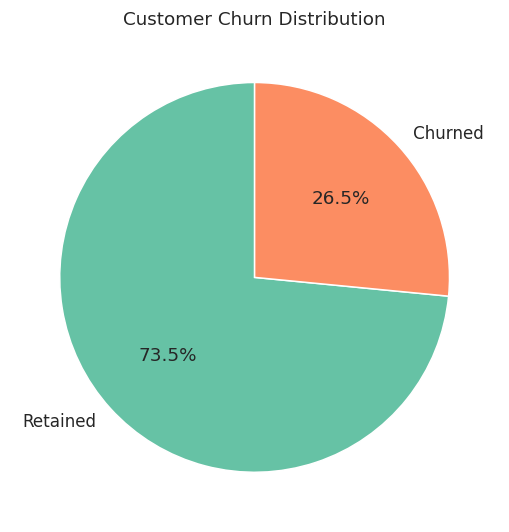

In [8]:
churn_counts = df_clean["Churn"].value_counts()
churn_rate = df_clean["Churn"].mean() * 100
print(f"Churned customers: {churn_counts[1]} ({churn_rate:.1f}%)")
print(f"Retained customers: {churn_counts[0]} ({100 - churn_rate:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(churn_counts, labels=["Retained", "Churned"], autopct="%1.1f%%",
       colors=["#66c2a5", "#fc8d62"], startangle=90, wedgeprops={"edgecolor": "white"})
ax.set_title("Customer Churn Distribution")
plt.tight_layout()
plt.savefig("images/01_churn_distribution.png", bbox_inches="tight")
plt.show()

The data is **imbalanced**: only about a quarter of the customers churn. A model that always predicts "No churn" would already be ~73% accurate, so accuracy alone is a misleading metric here. We will focus on **recall, F1-score and ROC-AUC**.

### 7.2 Churn rate for every category (ranked)

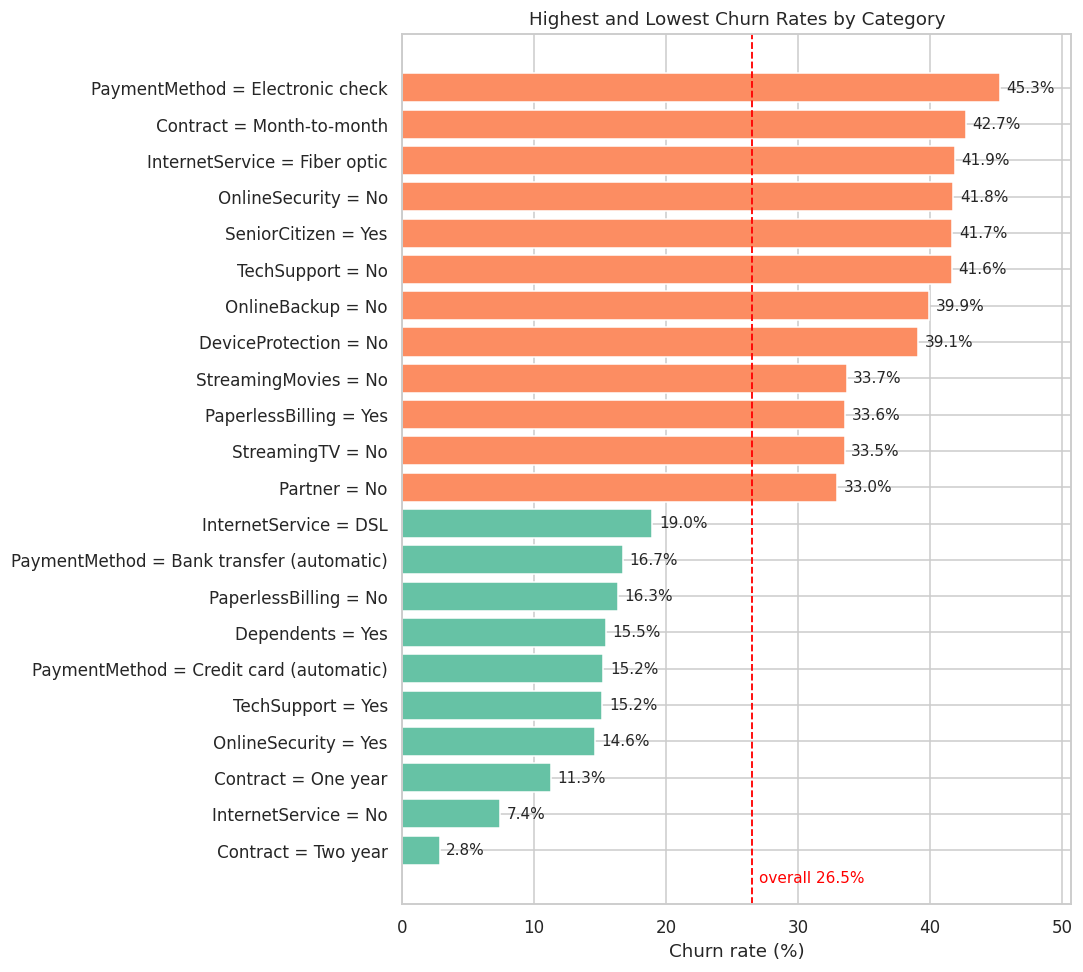

In [9]:
cat_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines",
            "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
            "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]

# Churn rate for every value of every categorical feature, ranked from highest to lowest
records = []
for col in cat_cols:
    for value, rate in (df_clean.groupby(col)["Churn"].mean() * 100).items():
        records.append({"Category": f"{col} = {value}", "ChurnRate": rate})
cat_rates = pd.DataFrame(records).sort_values("ChurnRate", ascending=False)
# "No internet service" rows repeat the same 7.4% for every add-on, so leave them out of the chart
cat_rates = cat_rates[~cat_rates["Category"].str.contains("No internet service|No phone service")]

# Show the 12 highest-churn and 10 lowest-churn categories
plot_df = pd.concat([cat_rates.head(12), cat_rates.tail(10)]).iloc[::-1]
colors = ["#fc8d62" if r > churn_rate else "#66c2a5" for r in plot_df["ChurnRate"]]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(plot_df["Category"], plot_df["ChurnRate"], color=colors)
for i, v in enumerate(plot_df["ChurnRate"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)
ax.axvline(churn_rate, color="red", linestyle="--", linewidth=1.2)
ax.text(churn_rate + 0.5, -0.9, f"overall {churn_rate:.1f}%", color="red", fontsize=10)
ax.set_xlabel("Churn rate (%)")
ax.set_title("Highest and Lowest Churn Rates by Category")
ax.set_xlim(0, plot_df["ChurnRate"].max() * 1.12)
plt.tight_layout()
plt.savefig("images/02_churn_by_categorical.png", bbox_inches="tight")
plt.show()

### 7.3 Contract type, internet service and payment method

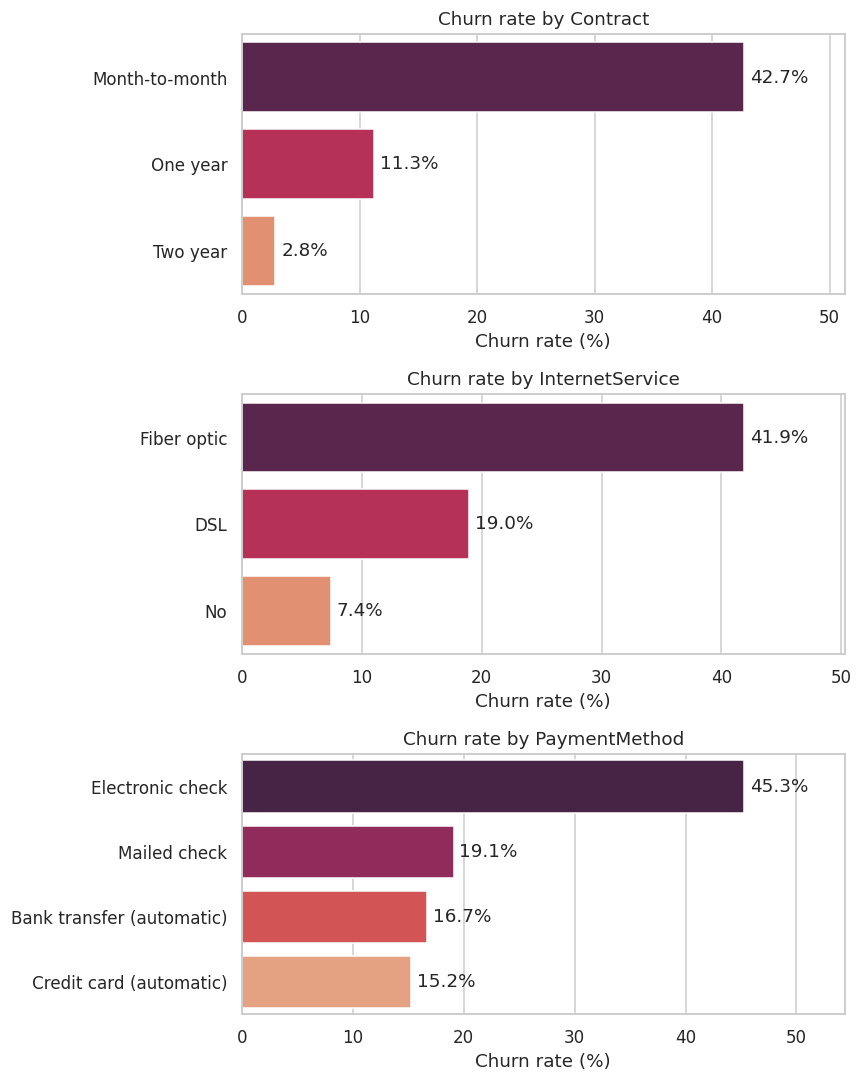

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    rate = df_clean.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, palette="rocket")
    for i, v in enumerate(rate.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, rate.max() * 1.2)
plt.tight_layout()
plt.savefig("images/03_contract_internet_payment.png", bbox_inches="tight")
plt.show()

print(df_clean.groupby("Contract")["Churn"].mean().mul(100).round(1))

### 7.4 Numeric features: tenure, monthly charges, total charges

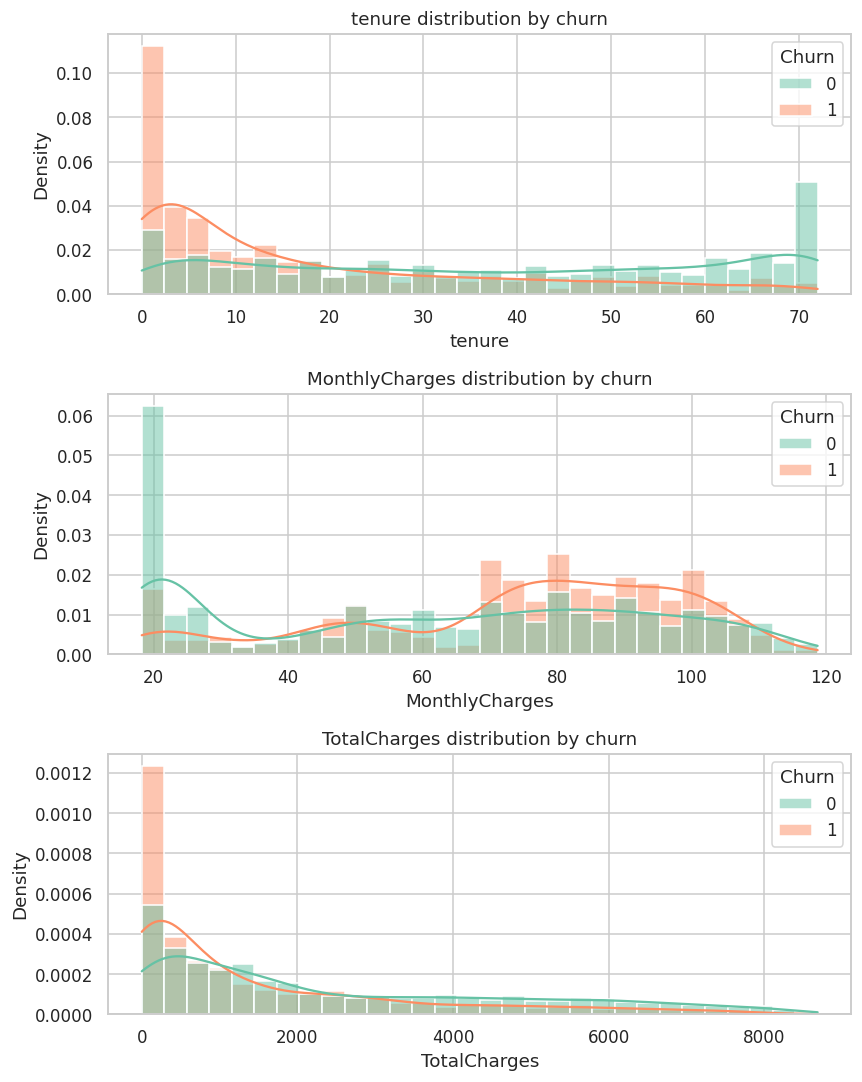

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.57,61.27,2549.91
1,17.98,74.44,1531.80


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df_clean, x=col, hue="Churn", kde=True, ax=ax, bins=30,
                 palette={0: "#66c2a5", 1: "#fc8d62"}, stat="density", common_norm=False)
    ax.set_title(f"{col} distribution by churn")
plt.tight_layout()
plt.savefig("images/04_numeric_distributions.png", bbox_inches="tight")
plt.show()

df_clean.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)

### 7.5 Churn rate across tenure

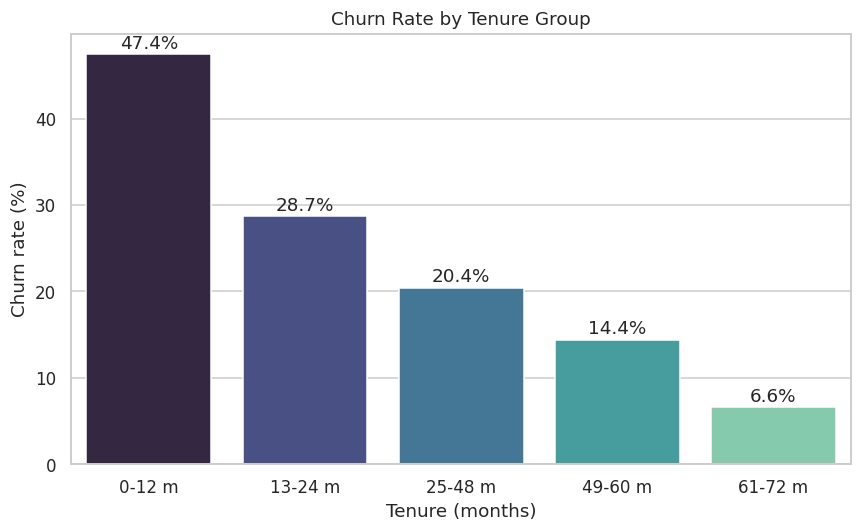

In [12]:
df_clean["tenure_group"] = pd.cut(df_clean["tenure"], bins=[-1, 12, 24, 48, 60, 72],
                                  labels=["0-12 m", "13-24 m", "25-48 m", "49-60 m", "61-72 m"])
tenure_rate = df_clean.groupby("tenure_group", observed=True)["Churn"].mean() * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=tenure_rate.index, y=tenure_rate.values, palette="mako")
for i, v in enumerate(tenure_rate.values):
    ax.text(i, v + 0.7, f"{v:.1f}%", ha="center")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn rate (%)")
plt.tight_layout()
plt.savefig("images/05_churn_by_tenure.png", bbox_inches="tight")
plt.show()

### 7.6 Correlation of numeric features

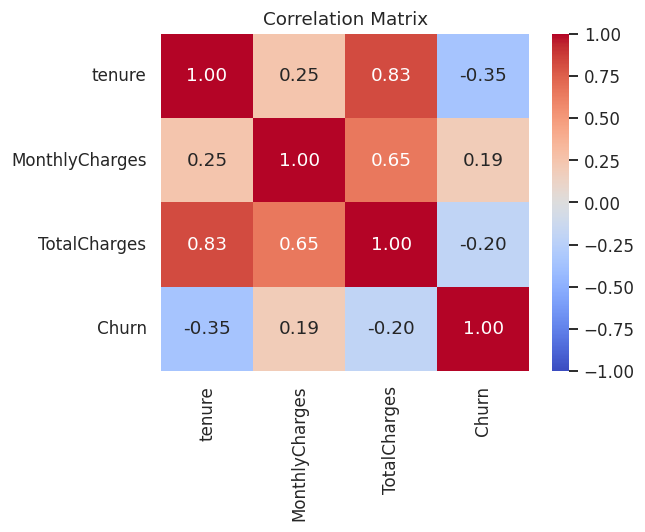

In [13]:
plt.figure(figsize=(6, 5))
corr = df_clean[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("images/06_correlation.png", bbox_inches="tight")
plt.show()

### EDA Findings
- **Contract type** is the strongest visible driver: month-to-month customers churn far more than one- or two-year customers.
- **New customers** (low tenure) churn the most; churn falls steadily as tenure grows.
- **Fiber optic** internet users and **electronic check** payers churn noticeably more than others.
- Customers **without Online Security or Tech Support** churn more than those who have them.
- Higher **monthly charges** are associated with more churn.
- **Gender** and **PhoneService** have almost no effect.

## 8. Feature Engineering

In [14]:
df_model = df_clean.copy()

# Number of add-on services a customer subscribes to
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
                "StreamingTV", "StreamingMovies"]
df_model["NumAddOnServices"] = (df_model[service_cols] == "Yes").sum(axis=1)

# Average amount paid per month of tenure (0 for brand-new customers)
df_model["AvgChargePerMonth"] = np.where(df_model["tenure"] > 0,
                                         df_model["TotalCharges"] / df_model["tenure"],
                                         df_model["MonthlyCharges"])

df_model = df_model.drop(columns=["tenure_group"])  # binned version is only for EDA
df_model[["NumAddOnServices", "AvgChargePerMonth"]].describe().round(2)

,NumAddOnServices,AvgChargePerMonth
count,7043.00,7043.00
mean,2.04,64.76
std,1.85,30.19
min,0.00,13.78
25%,0.00,35.94
50%,2.00,70.34
75%,3.00,90.17
max,6.00,121.40


## 9. Train / Test Split and Preprocessing

In [15]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "NumAddOnServices", "AvgChargePerMonth"]
categorical_features = [c for c in X.columns if c not in numeric_features]

# Stratified split keeps the churn ratio the same in train and test sets
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn rate  train: {y_train.mean():.3f}   test: {y_test.mean():.3f}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

Train: (5634, 21), Test: (1409, 21)
Churn rate  train: 0.265   test: 0.265


## 10. Model Building and Comparison
We compare three algorithms. Because of class imbalance, `class_weight="balanced"` is used where available so the models pay more attention to churners.

| Model | Why it is included |
|---|---|
| Logistic Regression | Simple, fast, interpretable baseline |
| Random Forest | Captures non-linear patterns and interactions |
| Gradient Boosting | Often the strongest on structured/tabular data |

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                                    random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}

for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = pipe
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "CV ROC-AUC (5-fold)": cv_auc,
    })

results = pd.DataFrame(rows).set_index("Model").round(4)
results.to_csv("results/model_comparison.csv")
results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC (5-fold)
Model,,,,,,
Logistic Regression,0.7395,0.5060,0.7861,0.6157,0.8418,0.8455
Random Forest,0.7608,0.5339,0.7781,0.6333,0.8436,0.8462
Gradient Boosting,0.7970,0.6549,0.4973,0.5653,0.8429,0.8471


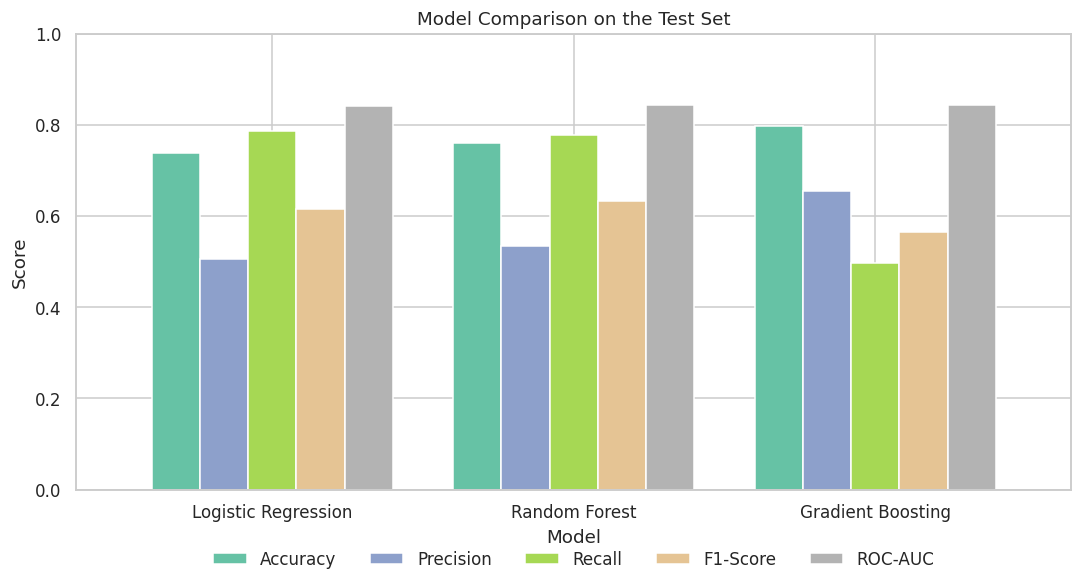

In [17]:
ax = results[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5.5), width=0.8, colormap="Set2")
plt.title("Model Comparison on the Test Set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5, frameon=False)
plt.tight_layout()
plt.savefig("images/07_model_comparison.png", bbox_inches="tight")
plt.show()

### ROC curves

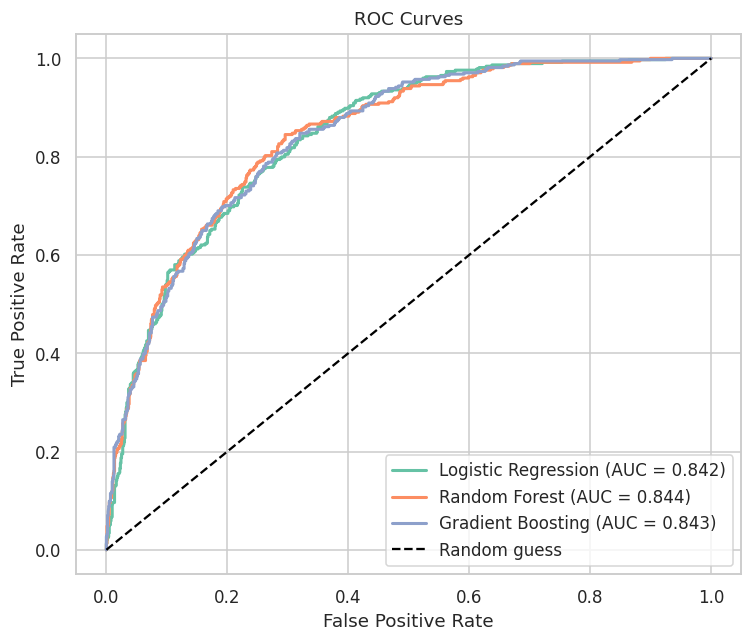

In [18]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {results.loc[name, 'ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig("images/08_roc_curves.png", bbox_inches="tight")
plt.show()

## 11. Hyperparameter Tuning

We tune the Logistic Regression and Gradient Boosting models with 5-fold cross-validation, optimising **ROC-AUC**.

In [19]:
tuning = {
    "Logistic Regression": (
        Pipeline([("prep", preprocessor),
                  ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
        {"model__C": [0.01, 0.1, 1, 10]},
    ),
    "Gradient Boosting": (
        Pipeline([("prep", preprocessor),
                  ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {"model__n_estimators": [100, 200],
         "model__learning_rate": [0.03, 0.05, 0.1],
         "model__max_depth": [2, 3]},
    ),
}

tuned, tuned_rows = {}, []
for name, (pipe, grid) in tuning.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs.best_estimator_
    proba = gs.best_estimator_.predict_proba(X_test)[:, 1]
    pred = gs.best_estimator_.predict(X_test)
    print(f"{name}: best params = {gs.best_params_}, CV AUC = {gs.best_score_:.4f}")
    tuned_rows.append({
        "Model": f"{name} (tuned)",
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

tuned_results = pd.DataFrame(tuned_rows).set_index("Model").round(4)
tuned_results.to_csv("results/tuned_model_results.csv")
tuned_results

Logistic Regression: best params = {'model__C': 10}, CV AUC = 0.8456


Gradient Boosting: best params = {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}, CV AUC = 0.8498


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (tuned),0.7388,0.5052,0.7834,0.6143,0.8408
Gradient Boosting (tuned),0.7956,0.6547,0.4866,0.5583,0.8458


## 12. Final Model Evaluation

Final model: Gradient Boosting

Classification report:

              precision    recall  f1-score   support

    Retained       0.83      0.91      0.87      1035
     Churned       0.65      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



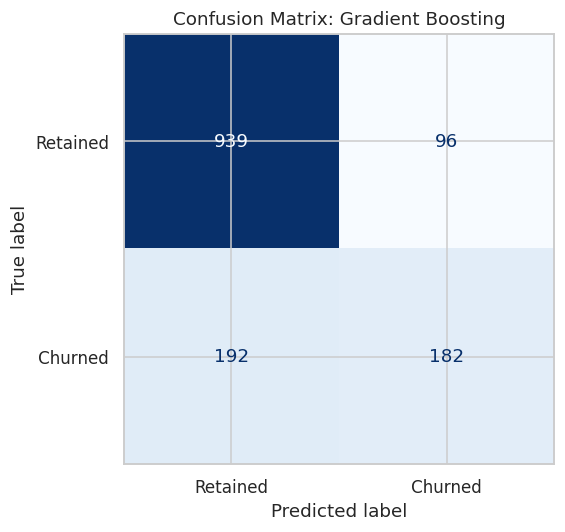

In [20]:
# Choose the final model: highest ROC-AUC on the test set among the tuned models
best_name = tuned_results["ROC-AUC"].idxmax().replace(" (tuned)", "")
best_model = tuned[best_name]
print("Final model:", best_name)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Retained", "Churned"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix: {best_name}")
plt.tight_layout()
plt.savefig("images/09_confusion_matrix.png", bbox_inches="tight")
plt.show()

### Precision-recall trade-off (choosing a decision threshold)

By default a customer is flagged as churner when the predicted probability is above 0.5. A retention team may prefer to catch *more* churners (higher recall) at the cost of contacting some customers who would have stayed. The table shows this trade-off.

In [21]:
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (y_proba >= t).astype(int)
    rows.append({"Threshold": t,
                 "Precision": precision_score(y_test, p),
                 "Recall": recall_score(y_test, p),
                 "F1-Score": f1_score(y_test, p),
                 "Customers flagged": int(p.sum())})
threshold_df = pd.DataFrame(rows).set_index("Threshold").round(3)
threshold_df.to_csv("results/threshold_tradeoff.csv")
threshold_df

,Precision,Recall,F1-Score,Customers flagged
Threshold,,,,
0.3,0.526,0.778,0.628,553
0.4,0.603,0.628,0.615,390
0.5,0.655,0.487,0.558,278
0.6,0.719,0.356,0.476,185
0.7,0.804,0.219,0.345,102


## 13. Model Explainability: What Drives Churn?

We use **permutation importance** on the original (un-encoded) columns. Each feature is randomly shuffled and we measure how much the model's ROC-AUC drops. A bigger drop means the model relies more on that feature.

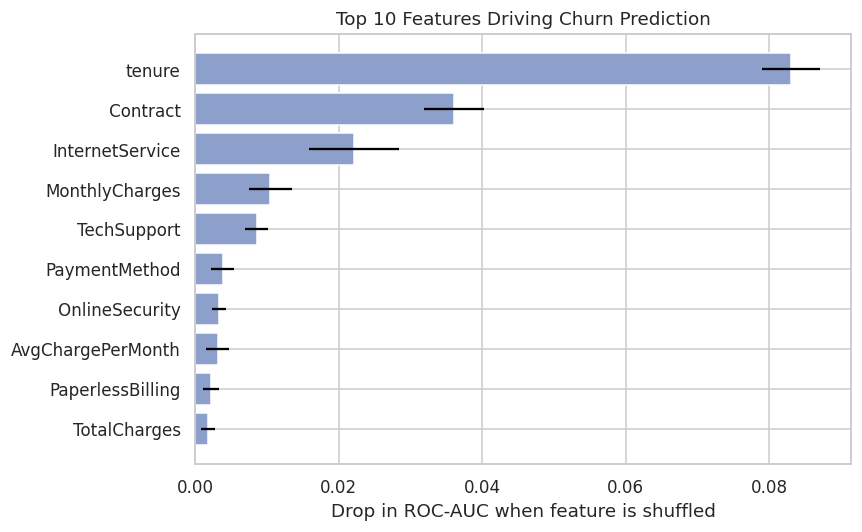

,Feature,Importance,Std
4,tenure,0.0830,0.0041
14,Contract,0.0361,0.0042
7,InternetService,0.0221,0.0063
17,MonthlyCharges,0.0105,0.0030
11,TechSupport,0.0085,0.0016
16,PaymentMethod,0.0038,0.0016
8,OnlineSecurity,0.0033,0.0010
20,AvgChargePerMonth,0.0031,0.0016
15,PaperlessBilling,0.0022,0.0011
18,TotalCharges,0.0018,0.0010


In [22]:
perm = permutation_importance(best_model, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"Feature": X_test.columns,
                            "Importance": perm.importances_mean,
                            "Std": perm.importances_std})
              .sort_values("Importance", ascending=False))
importance.to_csv("results/feature_importance.csv", index=False)

top = importance.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top["Feature"], top["Importance"], xerr=top["Std"], color="#8da0cb")
plt.xlabel("Drop in ROC-AUC when feature is shuffled")
plt.title("Top 10 Features Driving Churn Prediction")
plt.tight_layout()
plt.savefig("images/10_feature_importance.png", bbox_inches="tight")
plt.show()
importance.head(10).round(4)

## 14. Customer Risk Scoring

The model's churn probability is converted into a **risk segment**, which is how a business would actually use it: the retention team can prioritise the high-risk group first.

In [23]:
risk = pd.DataFrame({
    "customerID": id_test.values,
    "ChurnProbability": y_proba,
    "ActualChurn": y_test.values,
    "Contract": X_test["Contract"].values,
    "tenure": X_test["tenure"].values,
    "MonthlyCharges": X_test["MonthlyCharges"].values,
})
risk["RiskSegment"] = pd.cut(risk["ChurnProbability"], bins=[0, 0.3, 0.6, 1.0],
                             labels=["Low", "Medium", "High"], include_lowest=True)

segment_summary = (risk.groupby("RiskSegment", observed=True)
                   .agg(Customers=("customerID", "count"),
                        ActualChurnRate=("ActualChurn", "mean"),
                        AvgMonthlyCharges=("MonthlyCharges", "mean"))
                   .round(3))
segment_summary["ActualChurnRate"] = (segment_summary["ActualChurnRate"] * 100).round(1)
segment_summary = segment_summary.rename(columns={"ActualChurnRate": "ActualChurnRate (%)"})
segment_summary.to_csv("results/risk_segments.csv")
segment_summary

,Customers,ActualChurnRate (%),AvgMonthlyCharges
RiskSegment,,,
Low,856,9.7,57.210
Medium,368,42.9,72.539
High,185,71.9,79.109


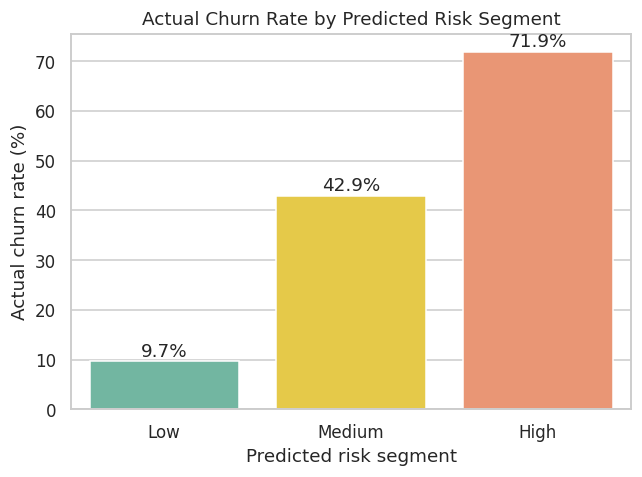

,customerID,ChurnProbability,ActualChurn,Contract,tenure,MonthlyCharges,RiskSegment
1090,5178-LMXOP,0.910,1,Month-to-month,1,95.10,High
1221,0295-PPHDO,0.898,1,Month-to-month,1,95.45,High
1109,1069-XAIEM,0.882,1,Month-to-month,1,85.05,High
344,6230-BSUXY,0.869,1,Month-to-month,1,85.00,High
51,7181-BQYBV,0.862,1,Month-to-month,1,102.45,High
83,0970-ETWGE,0.862,1,Month-to-month,1,89.55,High
1175,6861-XWTWQ,0.862,1,Month-to-month,7,99.25,High
1164,8884-ADFVN,0.862,1,Month-to-month,7,101.95,High
618,9248-OJYKK,0.861,1,Month-to-month,1,76.45,High
278,3722-WPXTK,0.857,1,Month-to-month,1,88.35,High


In [24]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(x=segment_summary.index, y=segment_summary["ActualChurnRate (%)"],
            palette=["#66c2a5", "#ffd92f", "#fc8d62"], ax=ax)
for i, v in enumerate(segment_summary["ActualChurnRate (%)"]):
    ax.text(i, v + 1, f"{v}%", ha="center")
ax.set_title("Actual Churn Rate by Predicted Risk Segment")
ax.set_ylabel("Actual churn rate (%)")
ax.set_xlabel("Predicted risk segment")
plt.tight_layout()
plt.savefig("images/11_risk_segments.png", bbox_inches="tight")
plt.show()

# Top 10 customers to contact first
top_risk = risk.sort_values("ChurnProbability", ascending=False).head(10).round(3)
top_risk.to_csv("results/top_10_high_risk_customers.csv", index=False)
top_risk

## 15. Save Key Results

In [25]:
summary = {
    "dataset_rows": int(df.shape[0]),
    "dataset_columns": int(df.shape[1]),
    "overall_churn_rate_pct": round(float(churn_rate), 2),
    "final_model": best_name,
    "final_metrics": {
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
        "precision": round(float(precision_score(y_test, y_pred)), 4),
        "recall": round(float(recall_score(y_test, y_pred)), 4),
        "f1": round(float(f1_score(y_test, y_pred)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, y_proba)), 4),
    },
}
with open("results/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
summary

{'dataset_rows': 7043,
 'dataset_columns': 21,
 'overall_churn_rate_pct': 26.54,
 'final_model': 'Gradient Boosting',
 'final_metrics': {'accuracy': 0.7956,
  'precision': 0.6547,
  'recall': 0.4866,
  'f1': 0.5583,
  'roc_auc': 0.8458}}

## 16. Conclusions

**Key findings from the analysis**
- The overall churn rate is **26.5%** (1,869 of 7,043 customers).
- **Contract type is the biggest business lever:** month-to-month customers churn at **42.7%**, versus 11.3% (one-year) and 2.8% (two-year).
- **Tenure is the strongest predictor:** customers in their first 12 months churn at **47.4%**, falling to 6.6% after 60 months.
- **Fiber optic** customers churn at **41.9%** (DSL: 19.0%) and **electronic check** payers at **45.3%** (automatic payments: about 15-17%).
- Customers **without Tech Support or Online Security** churn at roughly **42%**, against about 15% for those who have them.
- Churned customers pay more per month on average (**74.4 vs 61.3**) and are much newer (**18.0 vs 37.6 months** average tenure).
- Gender has no meaningful effect on churn.

**Model results**
- All three models reach a similar ROC-AUC of about **0.84-0.85**, so the data supports a reliable ranking of customers by churn risk.
- The final model (tuned Gradient Boosting) achieves ROC-AUC **0.846** and accuracy **79.6%** on unseen data, but at the default 0.5 threshold it catches only 48.7% of churners.
- Lowering the threshold to **0.3** raises recall to **77.8%** (precision 52.6%), which suits a retention campaign where missing a churner costs more than an extra phone call.
- The **risk segmentation works well**: customers flagged *High* risk actually churned **71.9%** of the time, *Medium* 42.9% and *Low* only 9.7%.

**Recommendations**
1. Offer discounts or incentives to move **month-to-month customers to 1- or 2-year contracts**.
2. Build a **first-year onboarding and check-in programme**, since new customers are the most likely to leave.
3. Bundle **Tech Support and Online Security** free or discounted for fiber optic customers.
4. Encourage a switch from **electronic check to automatic payment** with a small billing incentive.
5. Run the churn model monthly and hand the **High-risk list** to the retention team first.

**Limitations and future work**
- The dataset is a single snapshot with no time dimension, so we cannot see *when* behaviour changed before a customer left.
- No cost data is available; a real deployment should choose the threshold using the cost of a retention offer versus the value of a retained customer.
- Future work: try XGBoost/LightGBM, SHAP explanations, and deploy the model as a Streamlit dashboard.